# Visualisations pour le Mémoire - Classification des Maladies du Manioc

## Contenu:
1. Comparaison Gemma 3n vs Qwen2.5-VL-7B
2. Accuracy par classe (bar chart)
3. Matrice de confusion
4. Courbes d'apprentissage (loss)
5. Tableau récapitulatif
6. Distribution des prédictions

---

In [1]:
# ============================================================
# CELL 1: IMPORTS ET CONFIGURATION
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
import pandas as pd
from pathlib import Path
import json

# Style pour le mémoire (académique)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = 'serif'
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['legend.fontsize'] = 11
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['savefig.bbox'] = 'tight'

# Dossier de sauvegarde
FIGURES_DIR = Path("/home/hounfodjidagba/learning/cassava/new_implementation/figures_memoire")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"✅ Figures seront sauvegardées dans: {FIGURES_DIR}")

✅ Figures seront sauvegardées dans: /home/hounfodjidagba/learning/cassava/new_implementation/figures_memoire


In [2]:
# ============================================================
# CELL 2: DONNÉES DES RÉSULTATS
# ============================================================

# Résultats Gemma 3n V3.1
gemma_results = {
    'model': 'Gemma 3n (2B)',
    'global_accuracy': 65.05,
    'classes': {
        'CBB': 34.0,
        'CBSD': 2.9,
        'CGM': 81.4,
        'CMD': 89.4,
        'Healthy': 40.3
    },
    'val_loss_final': 1.0,
    'training_time_hours': 6.5,
    'hallucinations': 1
}

# Résultats Qwen2.5-VL-7B
qwen_results = {
    'model': 'Qwen2.5-VL (7B)',
    'global_accuracy': 80.52,
    'classes': {
        'CBB': 55.1,
        'CBSD': 84.0,
        'CGM': 56.5,
        'CMD': 86.0,
        'Healthy': 75.4
    },
    'val_loss_final': 0.07,
    'training_time_hours': 11.5,
    'hallucinations': 0
}

# Noms complets des classes
CLASS_FULL_NAMES = {
    'CBB': 'Cassava Bacterial Blight',
    'CBSD': 'Cassava Brown Streak Disease',
    'CGM': 'Cassava Green Mottle',
    'CMD': 'Cassava Mosaic Disease',
    'Healthy': 'Healthy'
}

# Distribution du test set
test_distribution = {
    'CBB': 156,
    'CBSD': 662,
    'CGM': 317,
    'CMD': 2082,
    'Healthy': 402
}

print("✅ Données chargées")
print(f"\nGemma: {gemma_results['global_accuracy']:.1f}% accuracy")
print(f"Qwen:  {qwen_results['global_accuracy']:.1f}% accuracy")

✅ Données chargées

Gemma: 65.0% accuracy
Qwen:  80.5% accuracy


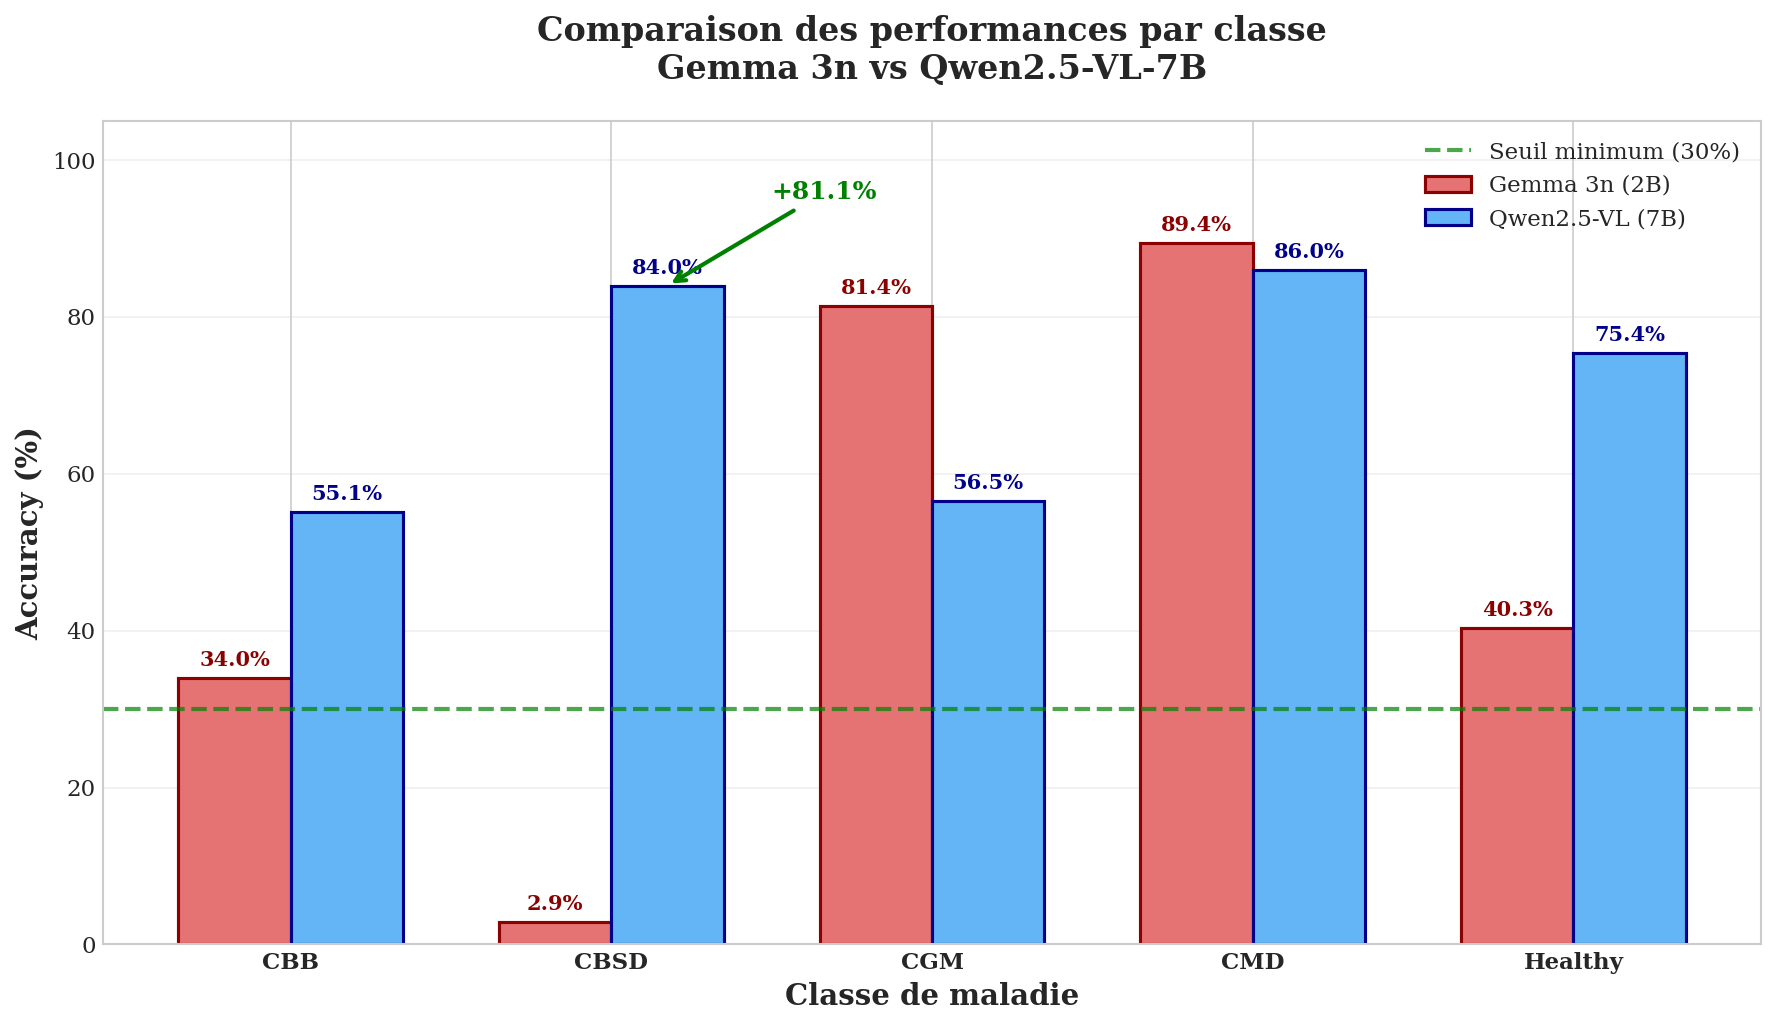


✅ Sauvegardé: /home/hounfodjidagba/learning/cassava/new_implementation/figures_memoire/comparaison_par_classe.png


In [3]:
# ============================================================
# CELL 3: COMPARAISON PAR CLASSE (BAR CHART)
# ============================================================

fig, ax = plt.subplots(figsize=(12, 7))

classes = list(gemma_results['classes'].keys())
gemma_acc = [gemma_results['classes'][c] for c in classes]
qwen_acc = [qwen_results['classes'][c] for c in classes]

x = np.arange(len(classes))
width = 0.35

# Couleurs
color_gemma = '#E57373'  # Rouge clair
color_qwen = '#64B5F6'   # Bleu clair

bars1 = ax.bar(x - width/2, gemma_acc, width, label='Gemma 3n (2B)', color=color_gemma, edgecolor='darkred', linewidth=1.5)
bars2 = ax.bar(x + width/2, qwen_acc, width, label='Qwen2.5-VL (7B)', color=color_qwen, edgecolor='darkblue', linewidth=1.5)

# Ajouter les valeurs sur les barres
for bar, val in zip(bars1, gemma_acc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.1f}%', 
            ha='center', va='bottom', fontsize=10, fontweight='bold', color='darkred')

for bar, val in zip(bars2, qwen_acc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.1f}%', 
            ha='center', va='bottom', fontsize=10, fontweight='bold', color='darkblue')

# Ligne de seuil à 30%
ax.axhline(y=30, color='green', linestyle='--', linewidth=2, alpha=0.7, label='Seuil minimum (30%)')

# Configuration
ax.set_xlabel('Classe de maladie', fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontweight='bold')
ax.set_title('Comparaison des performances par classe\nGemma 3n vs Qwen2.5-VL-7B', fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(classes, fontweight='bold')
ax.set_ylim(0, 105)
ax.legend(loc='upper right', framealpha=0.9)
ax.grid(axis='y', alpha=0.3)

# Annotations pour les améliorations majeures
ax.annotate('+81.1%', xy=(1 + width/2, 84), xytext=(1.5, 95),
            arrowprops=dict(arrowstyle='->', color='green', lw=2),
            fontsize=12, fontweight='bold', color='green')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'comparaison_par_classe.png', dpi=300, bbox_inches='tight')
plt.savefig(FIGURES_DIR / 'comparaison_par_classe.pdf', bbox_inches='tight')
plt.show()

print(f"\n✅ Sauvegardé: {FIGURES_DIR / 'comparaison_par_classe.png'}")

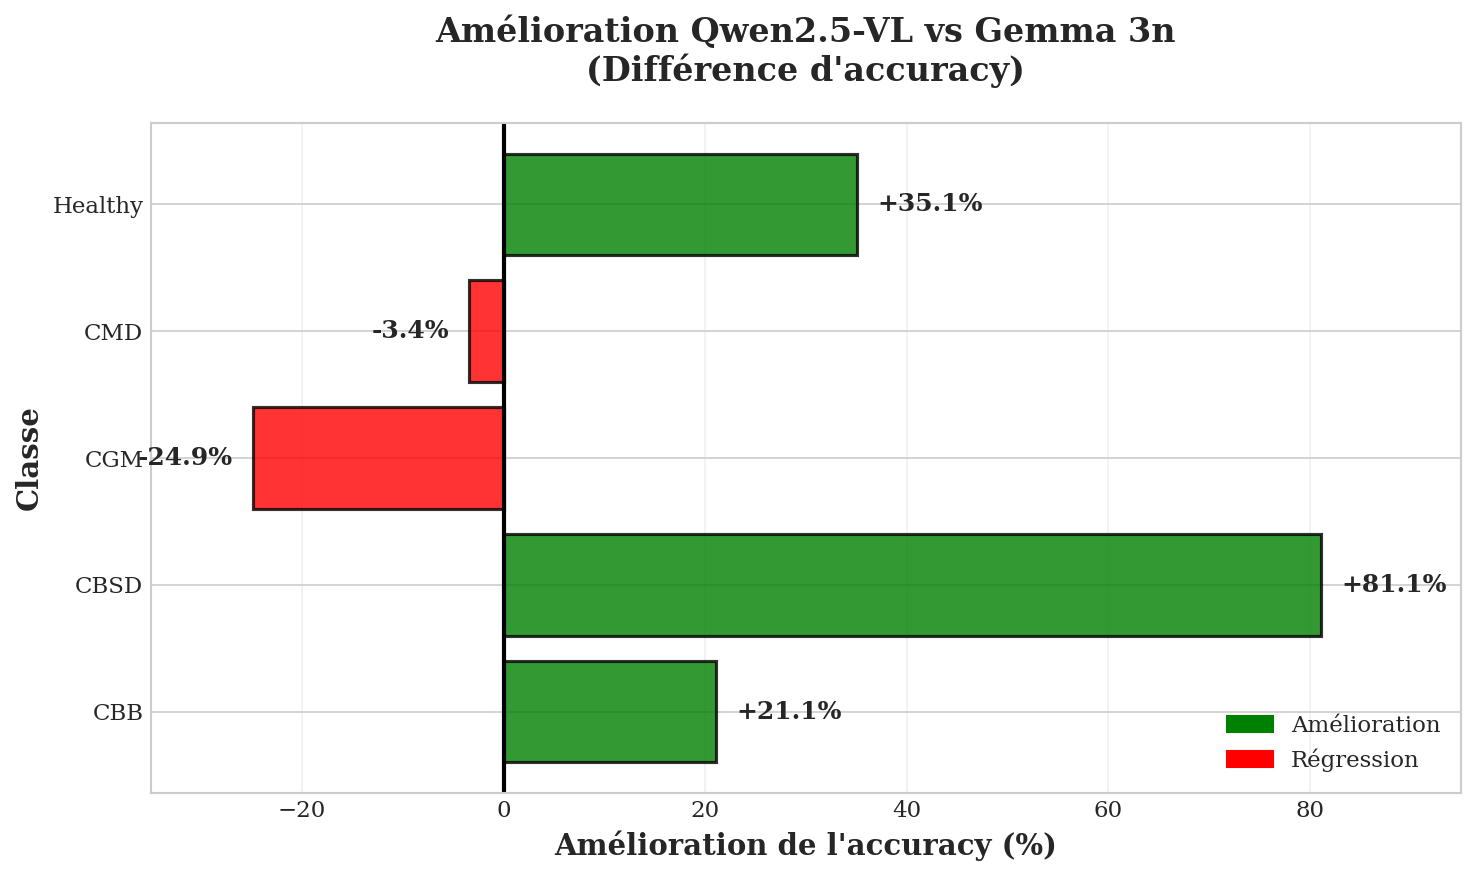


✅ Sauvegardé: /home/hounfodjidagba/learning/cassava/new_implementation/figures_memoire/amelioration_relative.png


In [4]:
# ============================================================
# CELL 4: AMÉLIORATION RELATIVE (DELTA)
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

# Calculer les différences
deltas = [qwen_results['classes'][c] - gemma_results['classes'][c] for c in classes]
colors = ['green' if d > 0 else 'red' for d in deltas]

bars = ax.barh(classes, deltas, color=colors, edgecolor='black', linewidth=1.5, alpha=0.8)

# Ajouter les valeurs
for bar, delta in zip(bars, deltas):
    x_pos = bar.get_width() + (2 if delta > 0 else -2)
    ha = 'left' if delta > 0 else 'right'
    ax.text(x_pos, bar.get_y() + bar.get_height()/2, f'{delta:+.1f}%', 
            ha=ha, va='center', fontsize=12, fontweight='bold')

# Ligne verticale à 0
ax.axvline(x=0, color='black', linewidth=2)

ax.set_xlabel('Amélioration de l\'accuracy (%)', fontweight='bold')
ax.set_ylabel('Classe', fontweight='bold')
ax.set_title('Amélioration Qwen2.5-VL vs Gemma 3n\n(Différence d\'accuracy)', fontweight='bold', pad=20)
ax.set_xlim(-35, 95)
ax.grid(axis='x', alpha=0.3)

# Légende
green_patch = mpatches.Patch(color='green', label='Amélioration')
red_patch = mpatches.Patch(color='red', label='Régression')
ax.legend(handles=[green_patch, red_patch], loc='lower right')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'amelioration_relative.png', dpi=300, bbox_inches='tight')
plt.savefig(FIGURES_DIR / 'amelioration_relative.pdf', bbox_inches='tight')
plt.show()

print(f"\n✅ Sauvegardé: {FIGURES_DIR / 'amelioration_relative.png'}")

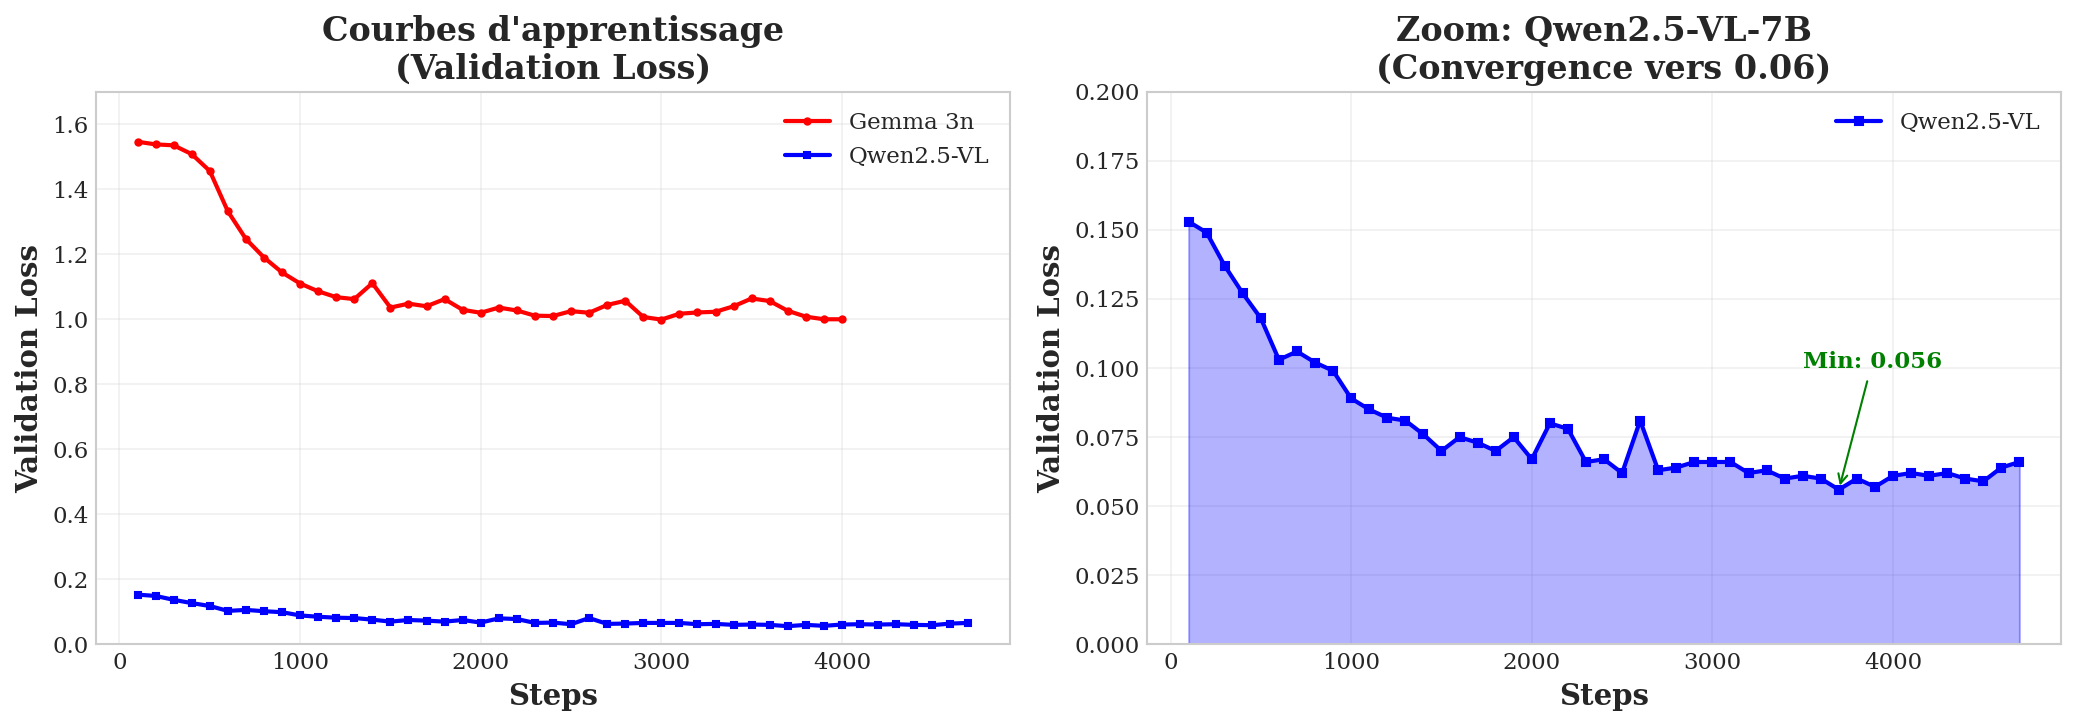


✅ Sauvegardé: /home/hounfodjidagba/learning/cassava/new_implementation/figures_memoire/courbes_apprentissage.png


In [5]:
# ============================================================
# CELL 5: COURBES D'APPRENTISSAGE (VALIDATION LOSS)
# ============================================================

# Données de training (extraites des logs)
# Gemma 3n
gemma_steps = [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400, 1500,
               1600, 1700, 1800, 1900, 2000, 2100, 2200, 2300, 2400, 2500, 2600, 2700, 2800,
               2900, 3000, 3100, 3200, 3300, 3400, 3500, 3600, 3700, 3800, 3900, 4000]
gemma_val_loss = [1.546, 1.538, 1.535, 1.508, 1.456, 1.332, 1.247, 1.190, 1.144, 1.110,
                  1.086, 1.068, 1.062, 1.111, 1.036, 1.048, 1.040, 1.062, 1.029, 1.020,
                  1.036, 1.027, 1.011, 1.010, 1.025, 1.020, 1.044, 1.057, 1.007, 0.999,
                  1.017, 1.021, 1.023, 1.040, 1.064, 1.056, 1.026, 1.008, 1.000, 1.000]

# Qwen2.5-VL
qwen_steps = [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400, 1500,
              1600, 1700, 1800, 1900, 2000, 2100, 2200, 2300, 2400, 2500, 2600, 2700, 2800,
              2900, 3000, 3100, 3200, 3300, 3400, 3500, 3600, 3700, 3800, 3900, 4000,
              4100, 4200, 4300, 4400, 4500, 4600, 4700]
qwen_val_loss = [0.153, 0.149, 0.137, 0.127, 0.118, 0.103, 0.106, 0.102, 0.099, 0.089,
                 0.085, 0.082, 0.081, 0.076, 0.070, 0.075, 0.073, 0.070, 0.075, 0.067,
                 0.080, 0.078, 0.066, 0.067, 0.062, 0.081, 0.063, 0.064, 0.066, 0.066,
                 0.066, 0.062, 0.063, 0.060, 0.061, 0.060, 0.056, 0.060, 0.057, 0.061,
                 0.062, 0.061, 0.062, 0.060, 0.059, 0.064, 0.066]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Les deux modèles
ax1.plot(gemma_steps, gemma_val_loss, 'r-', linewidth=2, label='Gemma 3n', marker='o', markersize=3)
ax1.plot(qwen_steps, qwen_val_loss, 'b-', linewidth=2, label='Qwen2.5-VL', marker='s', markersize=3)
ax1.set_xlabel('Steps', fontweight='bold')
ax1.set_ylabel('Validation Loss', fontweight='bold')
ax1.set_title('Courbes d\'apprentissage\n(Validation Loss)', fontweight='bold')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 1.7)

# Plot 2: Zoom sur Qwen
ax2.plot(qwen_steps, qwen_val_loss, 'b-', linewidth=2, label='Qwen2.5-VL', marker='s', markersize=4)
ax2.fill_between(qwen_steps, qwen_val_loss, alpha=0.3, color='blue')
ax2.set_xlabel('Steps', fontweight='bold')
ax2.set_ylabel('Validation Loss', fontweight='bold')
ax2.set_title('Zoom: Qwen2.5-VL-7B\n(Convergence vers 0.06)', fontweight='bold')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 0.2)

# Annotation
ax2.annotate(f'Min: {min(qwen_val_loss):.3f}', 
             xy=(qwen_steps[qwen_val_loss.index(min(qwen_val_loss))], min(qwen_val_loss)),
             xytext=(3500, 0.10),
             arrowprops=dict(arrowstyle='->', color='green'),
             fontsize=11, fontweight='bold', color='green')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'courbes_apprentissage.png', dpi=300, bbox_inches='tight')
plt.savefig(FIGURES_DIR / 'courbes_apprentissage.pdf', bbox_inches='tight')
plt.show()

print(f"\n✅ Sauvegardé: {FIGURES_DIR / 'courbes_apprentissage.png'}")

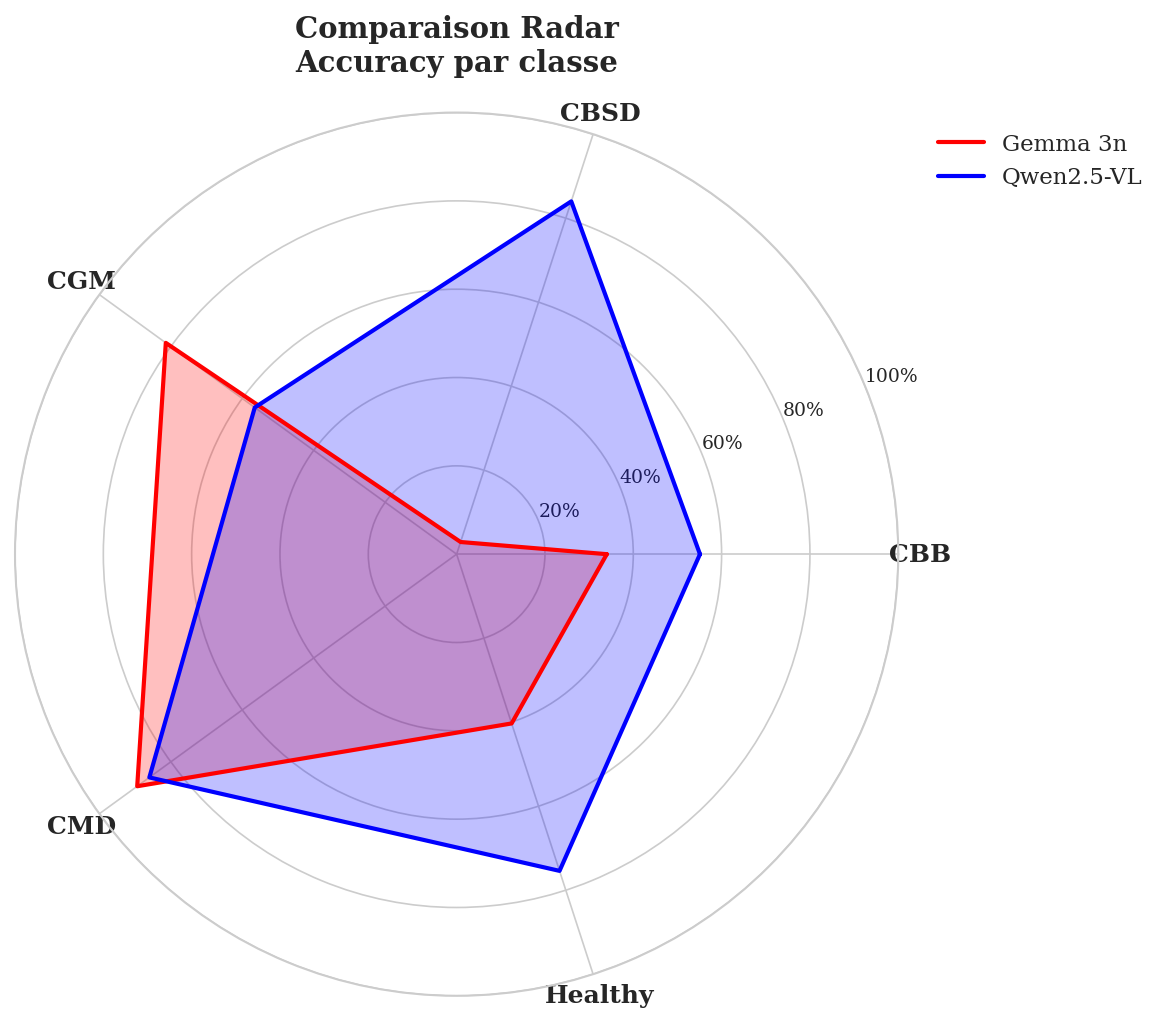


✅ Sauvegardé: /home/hounfodjidagba/learning/cassava/new_implementation/figures_memoire/radar_comparaison.png


In [6]:
# ============================================================
# CELL 6: RADAR CHART (COMPARAISON MULTI-DIMENSIONNELLE)
# ============================================================

from math import pi

# Données
categories = list(gemma_results['classes'].keys())
N = len(categories)

# Valeurs
gemma_values = [gemma_results['classes'][c] / 100 for c in categories]
qwen_values = [qwen_results['classes'][c] / 100 for c in categories]

# Fermer le radar
gemma_values += gemma_values[:1]
qwen_values += qwen_values[:1]

# Angles
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

# Plot
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# Gemma
ax.plot(angles, gemma_values, 'r-', linewidth=2, label='Gemma 3n')
ax.fill(angles, gemma_values, 'r', alpha=0.25)

# Qwen
ax.plot(angles, qwen_values, 'b-', linewidth=2, label='Qwen2.5-VL')
ax.fill(angles, qwen_values, 'b', alpha=0.25)

# Labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12, fontweight='bold')

# Y-axis
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['20%', '40%', '60%', '80%', '100%'], fontsize=9)

ax.set_title('Comparaison Radar\nAccuracy par classe', fontweight='bold', pad=20, fontsize=14)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'radar_comparaison.png', dpi=300, bbox_inches='tight')
plt.savefig(FIGURES_DIR / 'radar_comparaison.pdf', bbox_inches='tight')
plt.show()

print(f"\n✅ Sauvegardé: {FIGURES_DIR / 'radar_comparaison.png'}")

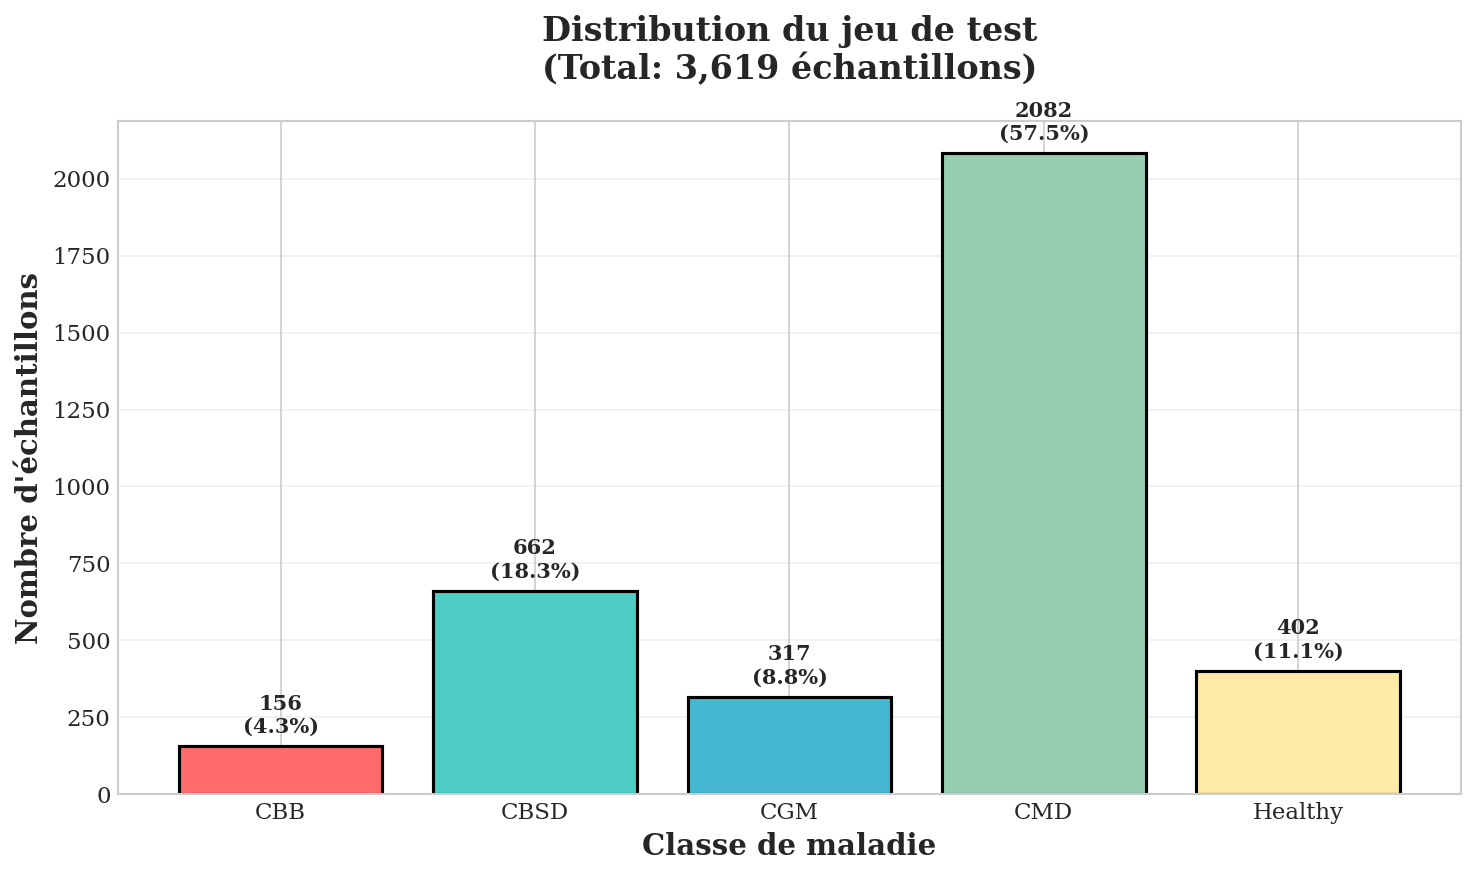


✅ Sauvegardé: /home/hounfodjidagba/learning/cassava/new_implementation/figures_memoire/distribution_test_set.png


In [7]:
# ============================================================
# CELL 7: DISTRIBUTION DU TEST SET
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

classes_names = list(test_distribution.keys())
counts = list(test_distribution.values())
total = sum(counts)
percentages = [c/total*100 for c in counts]

# Couleurs par classe
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']

bars = ax.bar(classes_names, counts, color=colors, edgecolor='black', linewidth=1.5)

# Ajouter les valeurs
for bar, count, pct in zip(bars, counts, percentages):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30, 
            f'{count}\n({pct:.1f}%)', 
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('Classe de maladie', fontweight='bold')
ax.set_ylabel('Nombre d\'échantillons', fontweight='bold')
ax.set_title(f'Distribution du jeu de test\n(Total: {total:,} échantillons)', fontweight='bold', pad=20)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'distribution_test_set.png', dpi=300, bbox_inches='tight')
plt.savefig(FIGURES_DIR / 'distribution_test_set.pdf', bbox_inches='tight')
plt.show()

print(f"\n✅ Sauvegardé: {FIGURES_DIR / 'distribution_test_set.png'}")


TABLEAU RÉCAPITULATIF - RÉSULTATS FINAUX
 Classe  Gemma 3n (%)  Qwen2.5-VL (%) Δ (points) Meilleur
    CBB         34.00           55.10      +21.1     Qwen
   CBSD          2.90           84.00      +81.1     Qwen
    CGM         81.40           56.50      -24.9    Gemma
    CMD         89.40           86.00       -3.4    Gemma
Healthy         40.30           75.40      +35.1     Qwen
 GLOBAL         65.05           80.52      +15.5     Qwen

✅ Tableau sauvegardé: /home/hounfodjidagba/learning/cassava/new_implementation/figures_memoire/resultats_comparaison.csv


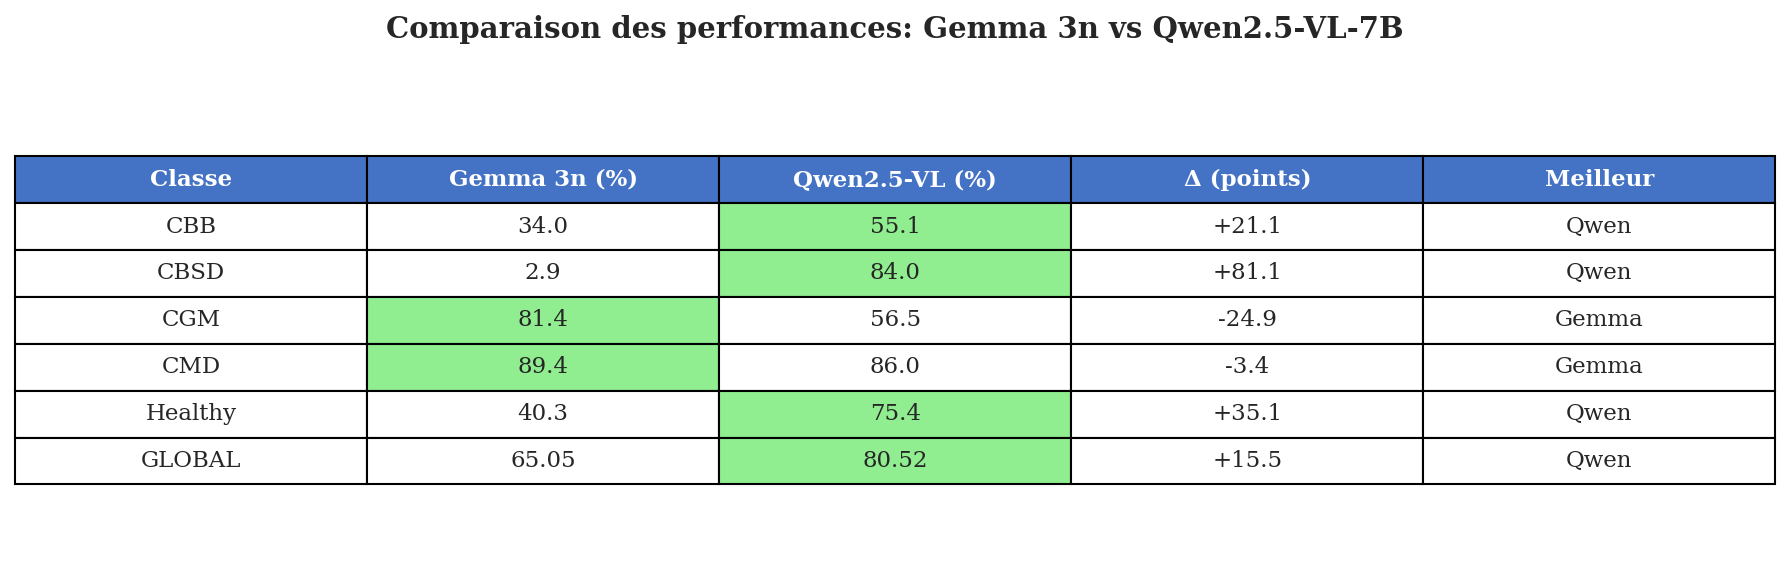

✅ Figure tableau sauvegardée: /home/hounfodjidagba/learning/cassava/new_implementation/figures_memoire/tableau_resultats.png


In [8]:
# ============================================================
# CELL 8: TABLEAU RÉCAPITULATIF (pour le mémoire)
# ============================================================

# Créer le DataFrame
data = {
    'Classe': ['CBB', 'CBSD', 'CGM', 'CMD', 'Healthy', 'GLOBAL'],
    'Gemma 3n (%)': [34.0, 2.9, 81.4, 89.4, 40.3, 65.05],
    'Qwen2.5-VL (%)': [55.1, 84.0, 56.5, 86.0, 75.4, 80.52],
    'Δ (points)': ['+21.1', '+81.1', '-24.9', '-3.4', '+35.1', '+15.5'],
    'Meilleur': ['Qwen', 'Qwen', 'Gemma', 'Gemma', 'Qwen', 'Qwen']
}

df = pd.DataFrame(data)

# Afficher
print("\n" + "="*70)
print("TABLEAU RÉCAPITULATIF - RÉSULTATS FINAUX")
print("="*70)
print(df.to_string(index=False))
print("="*70)

# Sauvegarder en CSV
df.to_csv(FIGURES_DIR / 'resultats_comparaison.csv', index=False)
print(f"\n✅ Tableau sauvegardé: {FIGURES_DIR / 'resultats_comparaison.csv'}")

# Créer une figure du tableau
fig, ax = plt.subplots(figsize=(12, 4))
ax.axis('off')

# Couleurs des cellules
cell_colors = []
for i, row in df.iterrows():
    row_colors = ['white'] * len(row)
    if row['Meilleur'] == 'Qwen':
        row_colors[2] = '#90EE90'  # Vert clair pour Qwen meilleur
    else:
        row_colors[1] = '#90EE90'  # Vert clair pour Gemma meilleur
    cell_colors.append(row_colors)

table = ax.table(
    cellText=df.values,
    colLabels=df.columns,
    cellColours=cell_colors,
    colColours=['#4472C4']*5,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)

# Style des headers
for i in range(len(df.columns)):
    table[(0, i)].set_text_props(color='white', fontweight='bold')

ax.set_title('Comparaison des performances: Gemma 3n vs Qwen2.5-VL-7B', 
             fontweight='bold', fontsize=14, pad=20)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'tableau_resultats.png', dpi=300, bbox_inches='tight')
plt.savefig(FIGURES_DIR / 'tableau_resultats.pdf', bbox_inches='tight')
plt.show()

print(f"✅ Figure tableau sauvegardée: {FIGURES_DIR / 'tableau_resultats.png'}")

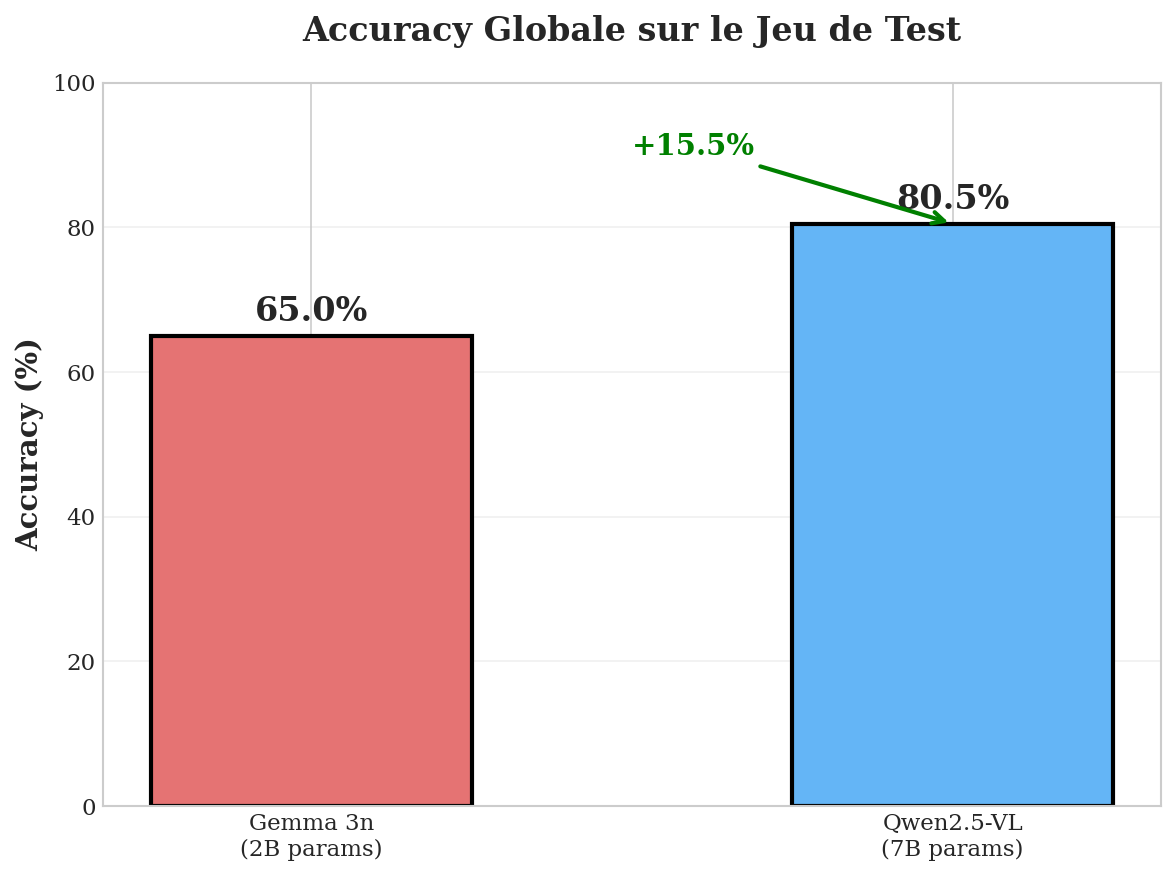


✅ Sauvegardé: /home/hounfodjidagba/learning/cassava/new_implementation/figures_memoire/accuracy_globale.png


In [9]:
# ============================================================
# CELL 9: ACCURACY GLOBALE (SIMPLE BAR)
# ============================================================

fig, ax = plt.subplots(figsize=(8, 6))

models = ['Gemma 3n\n(2B params)', 'Qwen2.5-VL\n(7B params)']
accuracies = [gemma_results['global_accuracy'], qwen_results['global_accuracy']]
colors = ['#E57373', '#64B5F6']

bars = ax.bar(models, accuracies, color=colors, edgecolor='black', linewidth=2, width=0.5)

# Valeurs sur les barres
for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
            f'{acc:.1f}%', ha='center', va='bottom', fontsize=16, fontweight='bold')

# Amélioration
improvement = qwen_results['global_accuracy'] - gemma_results['global_accuracy']
ax.annotate(f'+{improvement:.1f}%', xy=(1, qwen_results['global_accuracy']),
            xytext=(0.5, 90), fontsize=14, fontweight='bold', color='green',
            arrowprops=dict(arrowstyle='->', color='green', lw=2))

ax.set_ylabel('Accuracy (%)', fontweight='bold', fontsize=14)
ax.set_title('Accuracy Globale sur le Jeu de Test', fontweight='bold', fontsize=16, pad=20)
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'accuracy_globale.png', dpi=300, bbox_inches='tight')
plt.savefig(FIGURES_DIR / 'accuracy_globale.pdf', bbox_inches='tight')
plt.show()

print(f"\n✅ Sauvegardé: {FIGURES_DIR / 'accuracy_globale.png'}")

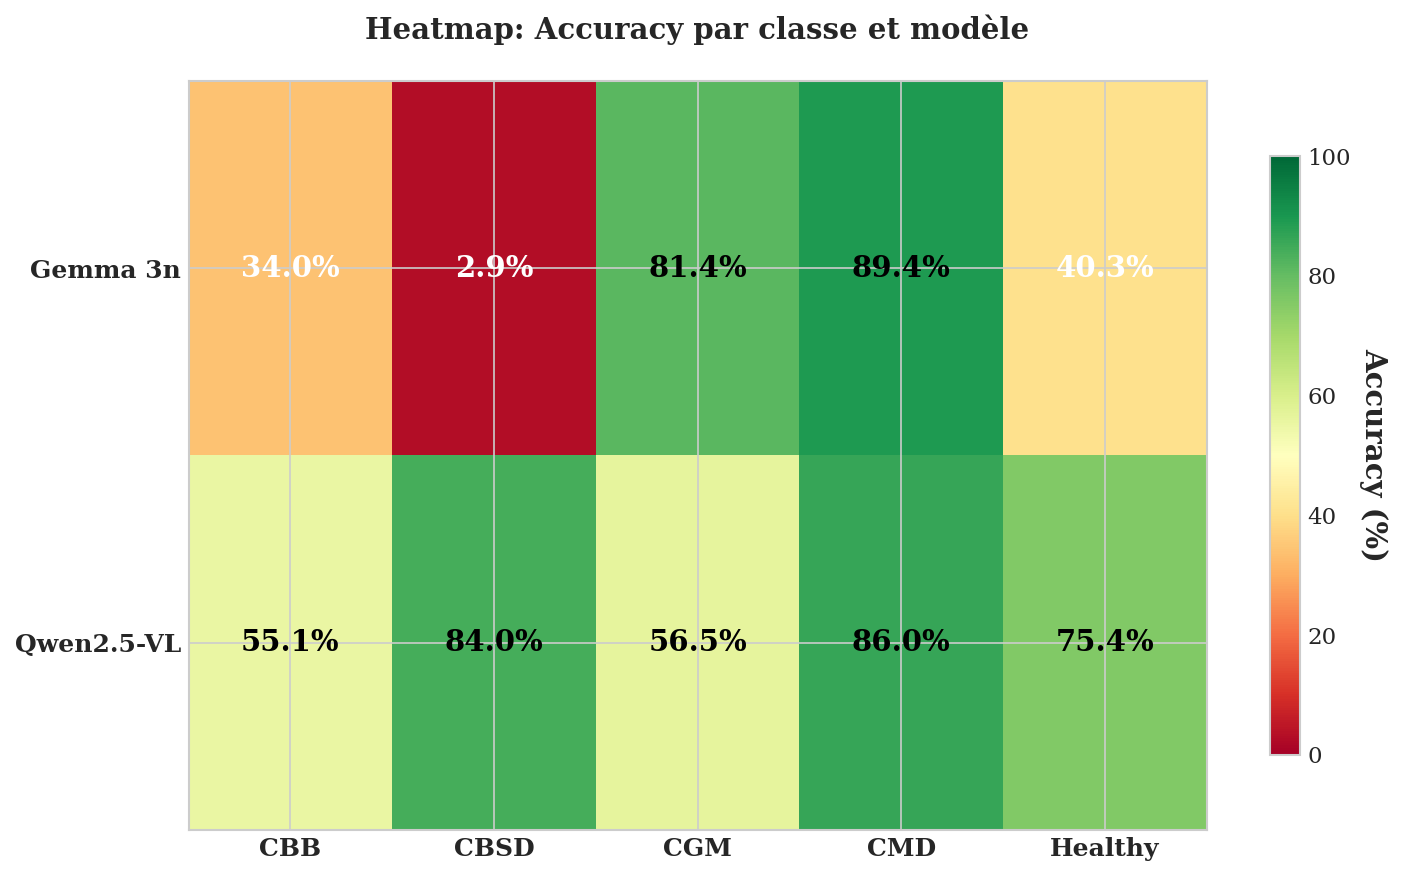


✅ Sauvegardé: /home/hounfodjidagba/learning/cassava/new_implementation/figures_memoire/heatmap_comparaison.png


In [10]:
# ============================================================
# CELL 10: HEATMAP COMPARAISON
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

# Données pour heatmap
heatmap_data = np.array([
    [gemma_results['classes'][c] for c in classes],
    [qwen_results['classes'][c] for c in classes]
])

# Créer la heatmap
im = ax.imshow(heatmap_data, cmap='RdYlGn', aspect='auto', vmin=0, vmax=100)

# Labels
ax.set_xticks(np.arange(len(classes)))
ax.set_yticks(np.arange(2))
ax.set_xticklabels(classes, fontweight='bold', fontsize=12)
ax.set_yticklabels(['Gemma 3n', 'Qwen2.5-VL'], fontweight='bold', fontsize=12)

# Ajouter les valeurs dans les cellules
for i in range(2):
    for j in range(len(classes)):
        value = heatmap_data[i, j]
        text_color = 'white' if value < 50 else 'black'
        ax.text(j, i, f'{value:.1f}%', ha='center', va='center', 
                fontweight='bold', fontsize=14, color=text_color)

# Colorbar
cbar = ax.figure.colorbar(im, ax=ax, shrink=0.8)
cbar.ax.set_ylabel('Accuracy (%)', rotation=-90, va='bottom', fontweight='bold')

ax.set_title('Heatmap: Accuracy par classe et modèle', fontweight='bold', fontsize=14, pad=20)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'heatmap_comparaison.png', dpi=300, bbox_inches='tight')
plt.savefig(FIGURES_DIR / 'heatmap_comparaison.pdf', bbox_inches='tight')
plt.show()

print(f"\n✅ Sauvegardé: {FIGURES_DIR / 'heatmap_comparaison.png'}")

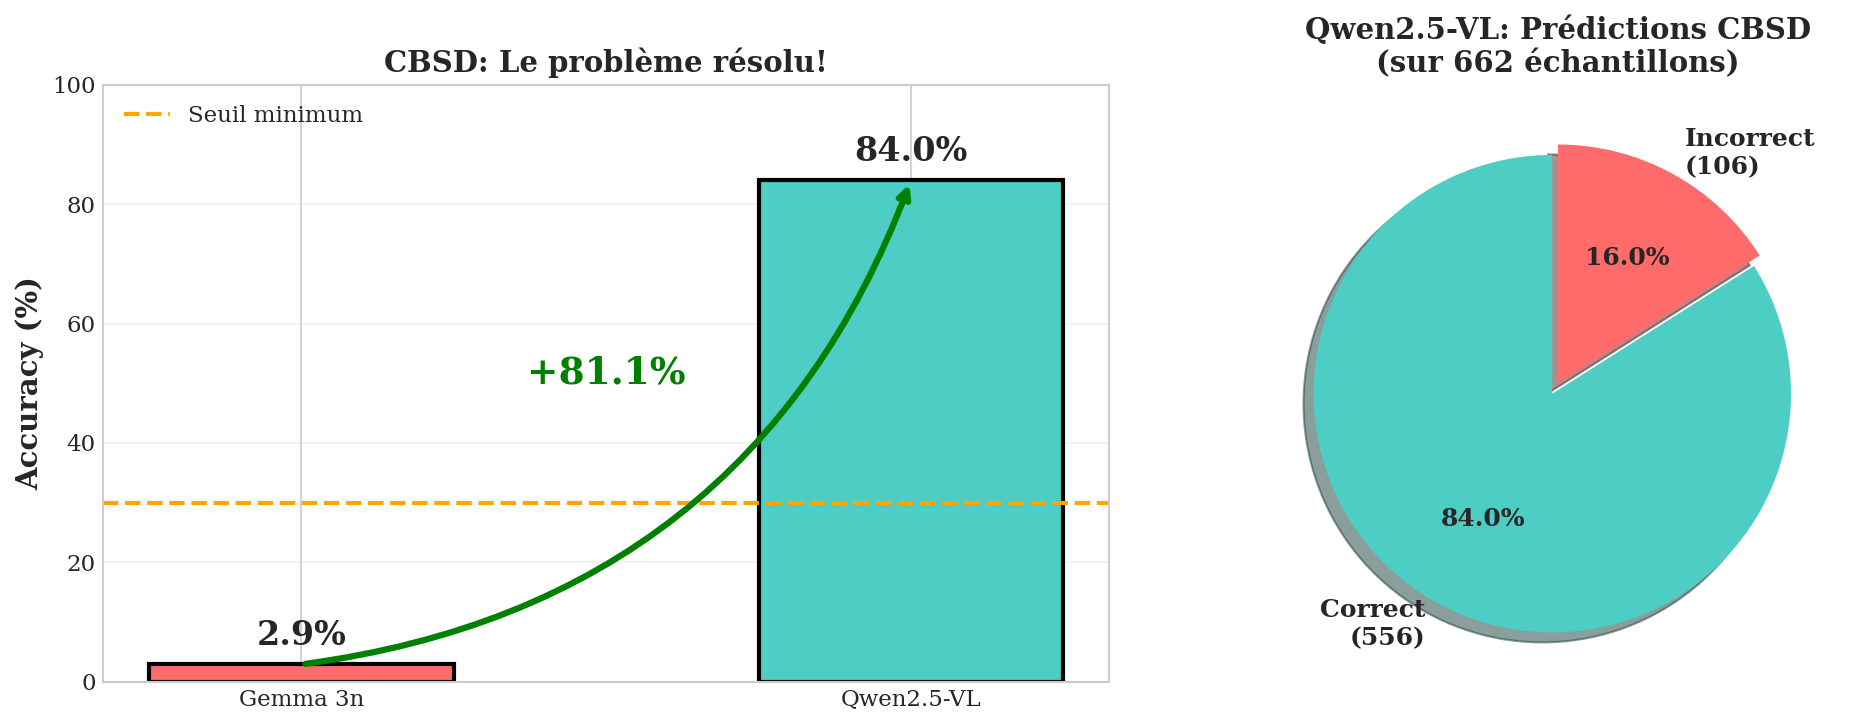


✅ Sauvegardé: /home/hounfodjidagba/learning/cassava/new_implementation/figures_memoire/focus_cbsd.png


In [11]:
# ============================================================
# CELL 11: FOCUS SUR CBSD (LE PROBLÈME RÉSOLU)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Avant/Après pour CBSD
ax1 = axes[0]
models = ['Gemma 3n', 'Qwen2.5-VL']
cbsd_acc = [gemma_results['classes']['CBSD'], qwen_results['classes']['CBSD']]
colors = ['#FF6B6B', '#4ECDC4']

bars = ax1.bar(models, cbsd_acc, color=colors, edgecolor='black', linewidth=2, width=0.5)

for bar, acc in zip(bars, cbsd_acc):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, 
            f'{acc:.1f}%', ha='center', va='bottom', fontsize=16, fontweight='bold')

# Flèche d'amélioration
ax1.annotate('', xy=(1, 84), xytext=(0, 2.9),
            arrowprops=dict(arrowstyle='->', color='green', lw=3, connectionstyle='arc3,rad=0.3'))
ax1.text(0.5, 50, '+81.1%', fontsize=18, fontweight='bold', color='green', ha='center')

ax1.axhline(y=30, color='orange', linestyle='--', linewidth=2, label='Seuil minimum')
ax1.set_ylabel('Accuracy (%)', fontweight='bold')
ax1.set_title('CBSD: Le problème résolu!', fontweight='bold', fontsize=14)
ax1.set_ylim(0, 100)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Plot 2: Pie chart de la performance Qwen sur CBSD
ax2 = axes[1]
cbsd_correct = int(662 * 0.84)  # 84% de 662
cbsd_incorrect = 662 - cbsd_correct

sizes = [cbsd_correct, cbsd_incorrect]
labels = [f'Correct\n({cbsd_correct})', f'Incorrect\n({cbsd_incorrect})']
colors = ['#4ECDC4', '#FF6B6B']
explode = (0.05, 0)

ax2.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
        shadow=True, startangle=90, textprops={'fontsize': 12, 'fontweight': 'bold'})
ax2.set_title(f'Qwen2.5-VL: Prédictions CBSD\n(sur {662} échantillons)', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'focus_cbsd.png', dpi=300, bbox_inches='tight')
plt.savefig(FIGURES_DIR / 'focus_cbsd.pdf', bbox_inches='tight')
plt.show()

print(f"\n✅ Sauvegardé: {FIGURES_DIR / 'focus_cbsd.png'}")

/tmp/ipykernel_2300835/2748601059.py:71: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])


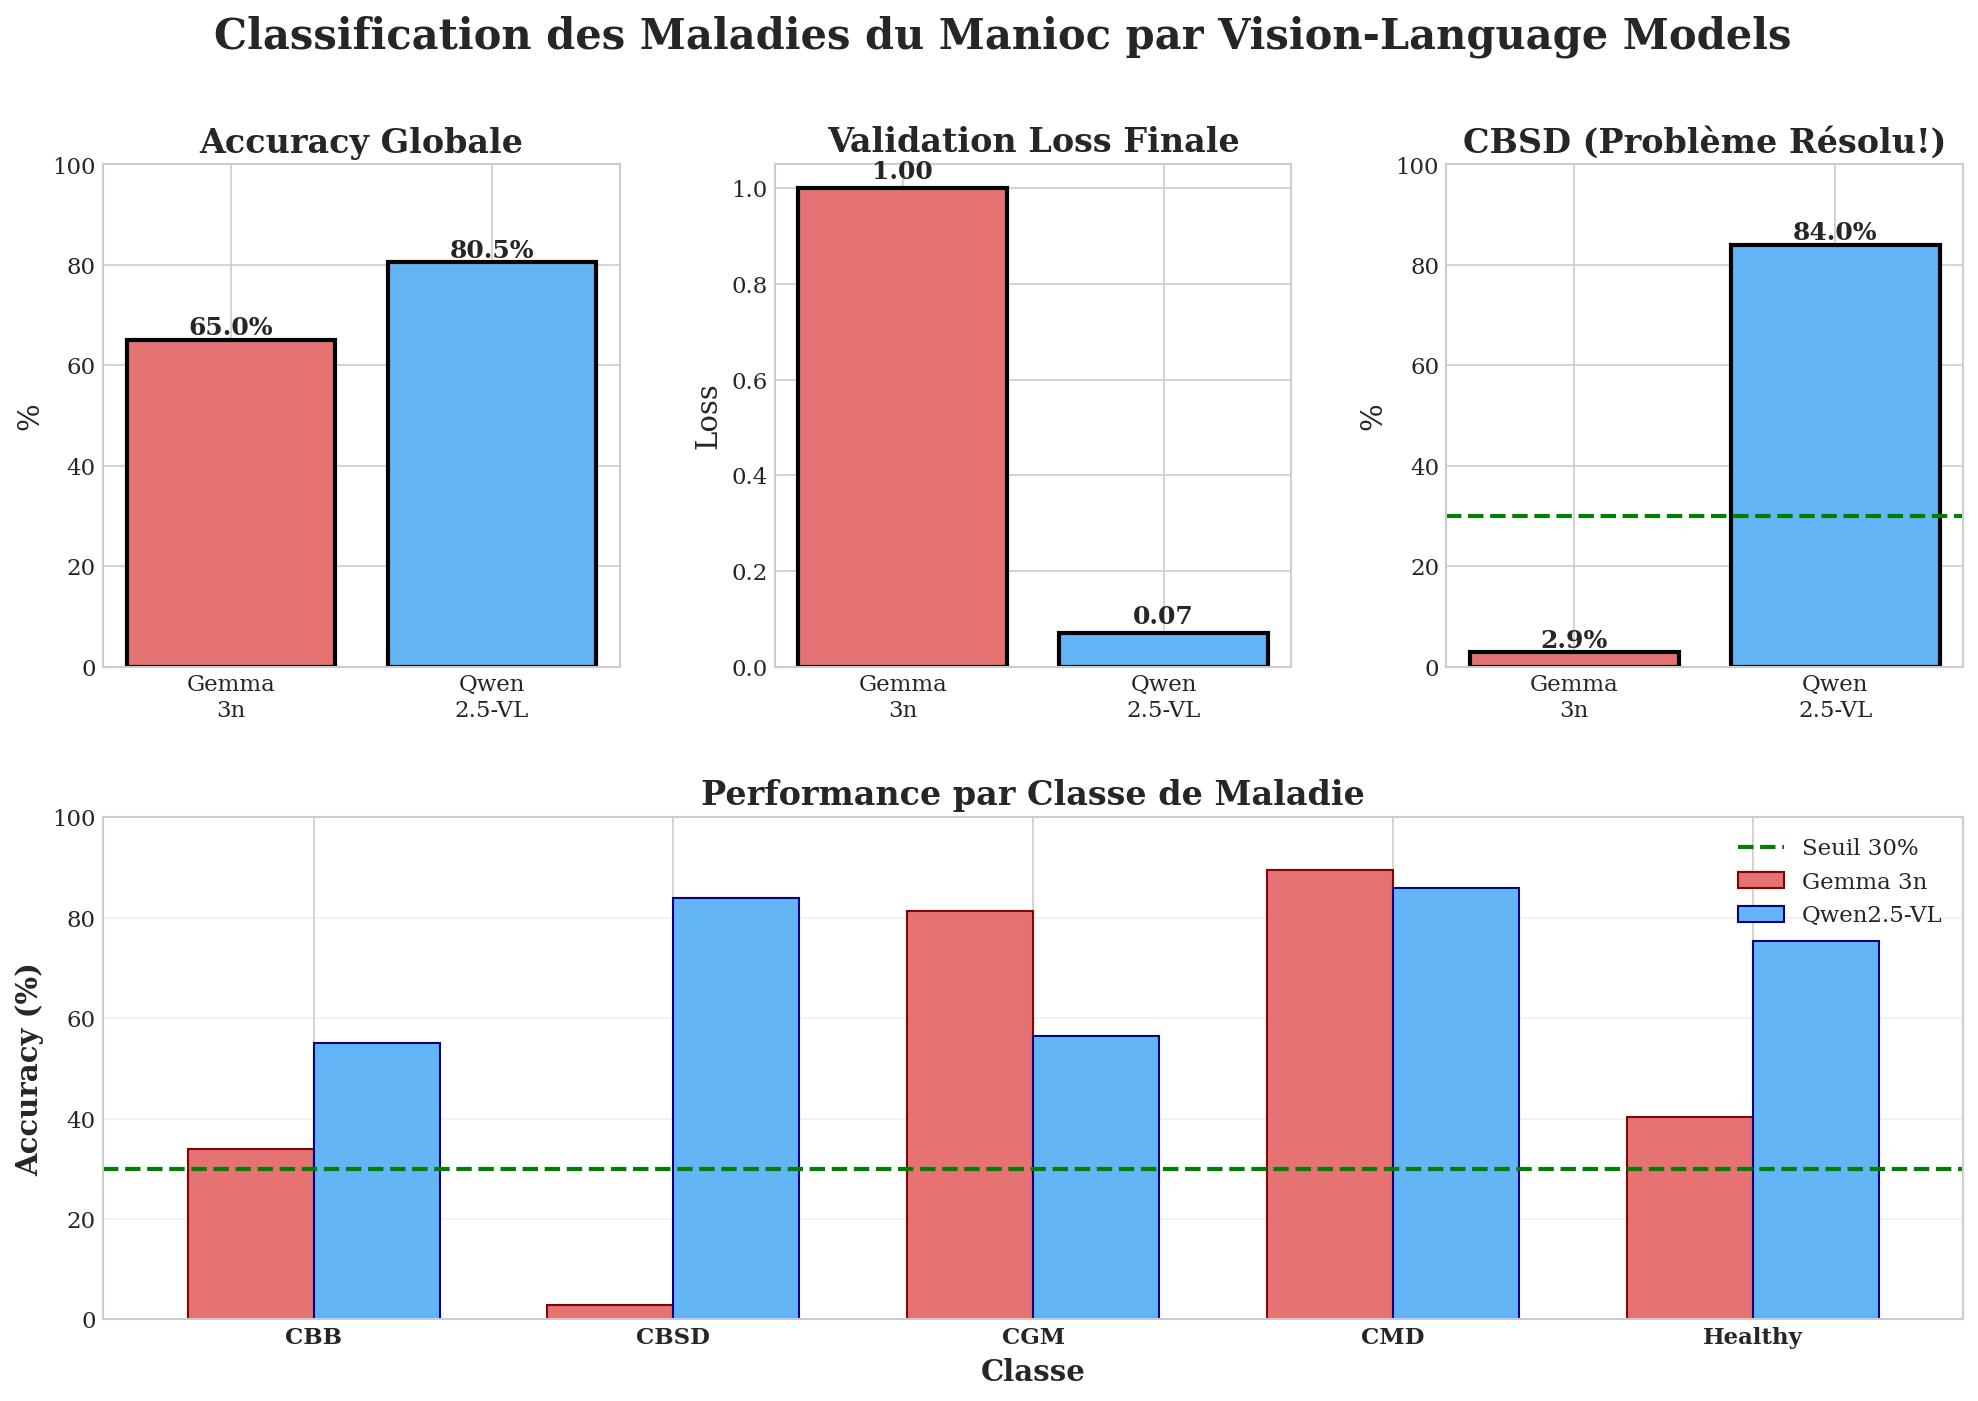


✅ Sauvegardé: /home/hounfodjidagba/learning/cassava/new_implementation/figures_memoire/infographie_resume.png


In [12]:
# ============================================================
# CELL 12: INFOGRAPHIE RÉSUMÉ
# ============================================================

fig = plt.figure(figsize=(16, 10))

# Titre principal
fig.suptitle('Classification des Maladies du Manioc par Vision-Language Models', 
             fontsize=20, fontweight='bold', y=0.98)

# Grille
gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)

# 1. Accuracy globale
ax1 = fig.add_subplot(gs[0, 0])
models = ['Gemma\n3n', 'Qwen\n2.5-VL']
accs = [65.05, 80.52]
bars = ax1.bar(models, accs, color=['#E57373', '#64B5F6'], edgecolor='black', linewidth=2)
for bar, acc in zip(bars, accs):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
            f'{acc:.1f}%', ha='center', fontsize=12, fontweight='bold')
ax1.set_title('Accuracy Globale', fontweight='bold')
ax1.set_ylim(0, 100)
ax1.set_ylabel('%')

# 2. Validation Loss
ax2 = fig.add_subplot(gs[0, 1])
models = ['Gemma\n3n', 'Qwen\n2.5-VL']
losses = [1.0, 0.07]
bars = ax2.bar(models, losses, color=['#E57373', '#64B5F6'], edgecolor='black', linewidth=2)
for bar, loss in zip(bars, losses):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
            f'{loss:.2f}', ha='center', fontsize=12, fontweight='bold')
ax2.set_title('Validation Loss Finale', fontweight='bold')
ax2.set_ylabel('Loss')

# 3. CBSD (problème résolu)
ax3 = fig.add_subplot(gs[0, 2])
models = ['Gemma\n3n', 'Qwen\n2.5-VL']
cbsd = [2.9, 84.0]
bars = ax3.bar(models, cbsd, color=['#E57373', '#64B5F6'], edgecolor='black', linewidth=2)
for bar, acc in zip(bars, cbsd):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
            f'{acc:.1f}%', ha='center', fontsize=12, fontweight='bold')
ax3.axhline(y=30, color='green', linestyle='--', linewidth=2)
ax3.set_title('CBSD (Problème Résolu!)', fontweight='bold')
ax3.set_ylim(0, 100)
ax3.set_ylabel('%')

# 4. Comparaison par classe (bottom - full width)
ax4 = fig.add_subplot(gs[1, :])
x = np.arange(5)
width = 0.35
classes = ['CBB', 'CBSD', 'CGM', 'CMD', 'Healthy']
gemma_acc = [34.0, 2.9, 81.4, 89.4, 40.3]
qwen_acc = [55.1, 84.0, 56.5, 86.0, 75.4]

bars1 = ax4.bar(x - width/2, gemma_acc, width, label='Gemma 3n', color='#E57373', edgecolor='darkred')
bars2 = ax4.bar(x + width/2, qwen_acc, width, label='Qwen2.5-VL', color='#64B5F6', edgecolor='darkblue')

ax4.axhline(y=30, color='green', linestyle='--', linewidth=2, label='Seuil 30%')
ax4.set_xlabel('Classe', fontweight='bold')
ax4.set_ylabel('Accuracy (%)', fontweight='bold')
ax4.set_title('Performance par Classe de Maladie', fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(classes, fontweight='bold')
ax4.set_ylim(0, 100)
ax4.legend(loc='upper right')
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(FIGURES_DIR / 'infographie_resume.png', dpi=300, bbox_inches='tight')
plt.savefig(FIGURES_DIR / 'infographie_resume.pdf', bbox_inches='tight')
plt.show()

print(f"\n✅ Sauvegardé: {FIGURES_DIR / 'infographie_resume.png'}")

In [13]:
# ============================================================
# CELL 13: LISTE DES FIGURES GÉNÉRÉES
# ============================================================

print("\n" + "="*70)
print("FIGURES GÉNÉRÉES POUR LE MÉMOIRE")
print("="*70)

figures = list(FIGURES_DIR.glob('*'))
figures.sort()

print(f"\nDossier: {FIGURES_DIR}")
print(f"\nFichiers générés ({len(figures)}):")

for fig in figures:
    size = fig.stat().st_size / 1024  # KB
    print(f"  📊 {fig.name} ({size:.1f} KB)")

print("\n" + "="*70)
print("UTILISATION DANS LE MÉMOIRE:")
print("="*70)
print("""
1. comparaison_par_classe.png - Figure principale de comparaison
2. amelioration_relative.png  - Montre les gains/pertes par classe
3. courbes_apprentissage.png  - Évolution de la validation loss
4. radar_comparaison.png      - Vue multi-dimensionnelle
5. distribution_test_set.png  - Déséquilibre des classes
6. tableau_resultats.png      - Tableau récapitulatif
7. accuracy_globale.png       - Comparaison simple
8. heatmap_comparaison.png    - Vue matricielle
9. focus_cbsd.png             - Mise en avant du problème résolu
10. infographie_resume.png    - Résumé visuel complet
""")
print("="*70)


FIGURES GÉNÉRÉES POUR LE MÉMOIRE

Dossier: /home/hounfodjidagba/learning/cassava/new_implementation/figures_memoire

Fichiers générés (21):
  📊 accuracy_globale.pdf (22.1 KB)
  📊 accuracy_globale.png (121.6 KB)
  📊 amelioration_relative.pdf (27.2 KB)
  📊 amelioration_relative.png (169.9 KB)
  📊 comparaison_par_classe.pdf (29.4 KB)
  📊 comparaison_par_classe.png (225.3 KB)
  📊 courbes_apprentissage.pdf (26.7 KB)
  📊 courbes_apprentissage.png (252.7 KB)
  📊 distribution_test_set.pdf (23.4 KB)
  📊 distribution_test_set.png (173.8 KB)
  📊 focus_cbsd.pdf (29.0 KB)
  📊 focus_cbsd.png (261.2 KB)
  📊 heatmap_comparaison.pdf (28.1 KB)
  📊 heatmap_comparaison.png (166.5 KB)
  📊 infographie_resume.pdf (31.1 KB)
  📊 infographie_resume.png (321.5 KB)
  📊 radar_comparaison.pdf (22.3 KB)
  📊 radar_comparaison.png (366.1 KB)
  📊 resultats_comparaison.csv (0.2 KB)
  📊 tableau_resultats.pdf (26.8 KB)
  📊 tableau_resultats.png (180.7 KB)

UTILISATION DANS LE MÉMOIRE:

1. comparaison_par_classe.png - Fig

In [14]:
# ============================================================
# CELL 14: EXPORT DONNÉES POUR LATEX
# ============================================================

# Générer le tableau LaTeX
latex_table = r"""
\begin{table}[h]
\centering
\caption{Comparaison des performances: Gemma 3n vs Qwen2.5-VL-7B}
\label{tab:comparaison_modeles}
\begin{tabular}{lcccc}
\hline
\textbf{Classe} & \textbf{Gemma 3n (\%)} & \textbf{Qwen2.5-VL (\%)} & \textbf{$\Delta$ (pts)} & \textbf{Meilleur} \\
\hline
CBB & 34.0 & 55.1 & +21.1 & Qwen \\
CBSD & 2.9 & \textbf{84.0} & \textbf{+81.1} & Qwen \\
CGM & \textbf{81.4} & 56.5 & -24.9 & Gemma \\
CMD & 89.4 & 86.0 & -3.4 & Gemma \\
Healthy & 40.3 & 75.4 & +35.1 & Qwen \\
\hline
\textbf{Global} & 65.05 & \textbf{80.52} & \textbf{+15.5} & \textbf{Qwen} \\
\hline
\end{tabular}
\end{table}
"""

# Sauvegarder
with open(FIGURES_DIR / 'tableau_latex.tex', 'w') as f:
    f.write(latex_table)

print("✅ Tableau LaTeX sauvegardé: tableau_latex.tex")
print("\nContenu:")
print(latex_table)

✅ Tableau LaTeX sauvegardé: tableau_latex.tex

Contenu:

\begin{table}[h]
\centering
\caption{Comparaison des performances: Gemma 3n vs Qwen2.5-VL-7B}
\label{tab:comparaison_modeles}
\begin{tabular}{lcccc}
\hline
\textbf{Classe} & \textbf{Gemma 3n (\%)} & \textbf{Qwen2.5-VL (\%)} & \textbf{$\Delta$ (pts)} & \textbf{Meilleur} \\
\hline
CBB & 34.0 & 55.1 & +21.1 & Qwen \\
CBSD & 2.9 & \textbf{84.0} & \textbf{+81.1} & Qwen \\
CGM & \textbf{81.4} & 56.5 & -24.9 & Gemma \\
CMD & 89.4 & 86.0 & -3.4 & Gemma \\
Healthy & 40.3 & 75.4 & +35.1 & Qwen \\
\hline
\textbf{Global} & 65.05 & \textbf{80.52} & \textbf{+15.5} & \textbf{Qwen} \\
\hline
\end{tabular}
\end{table}



In [15]:
# ============================================================
# CELL 15: MÉTRIQUES SUPPLÉMENTAIRES
# ============================================================

print("\n" + "="*70)
print("MÉTRIQUES SUPPLÉMENTAIRES POUR LE MÉMOIRE")
print("="*70)

# Calculs
improvement_global = qwen_results['global_accuracy'] - gemma_results['global_accuracy']
improvement_cbsd = qwen_results['classes']['CBSD'] - gemma_results['classes']['CBSD']
loss_reduction = (gemma_results['val_loss_final'] - qwen_results['val_loss_final']) / gemma_results['val_loss_final'] * 100

print(f"""
📊 RÉSUMÉ DES AMÉLIORATIONS:

• Accuracy globale: +{improvement_global:.1f} points ({gemma_results['global_accuracy']:.1f}% → {qwen_results['global_accuracy']:.1f}%)
• Amélioration relative: +{improvement_global/gemma_results['global_accuracy']*100:.1f}%

• CBSD (problème résolu): +{improvement_cbsd:.1f} points ({gemma_results['classes']['CBSD']:.1f}% → {qwen_results['classes']['CBSD']:.1f}%)
• Amélioration CBSD: +{improvement_cbsd/max(gemma_results['classes']['CBSD'], 0.1)*100:.0f}%

• Validation Loss: -{loss_reduction:.1f}% ({gemma_results['val_loss_final']:.2f} → {qwen_results['val_loss_final']:.2f})
• Rapport de loss: {gemma_results['val_loss_final']/qwen_results['val_loss_final']:.1f}x meilleur

• Classes > 50%: Gemma = 2/5, Qwen = 5/5 ✓
• Hallucinations: Gemma = {gemma_results['hallucinations']}, Qwen = {qwen_results['hallucinations']} ✓

📈 STATISTIQUES D'ENTRAÎNEMENT:

• Gemma 3n:
  - Paramètres: 2B (effectifs)
  - Temps: {gemma_results['training_time_hours']:.1f} heures
  - Steps: ~4000

• Qwen2.5-VL:
  - Paramètres: 7B
  - Temps: {qwen_results['training_time_hours']:.1f} heures
  - Steps: ~4700
""")

# Sauvegarder les métriques en JSON
metrics = {
    'gemma': gemma_results,
    'qwen': qwen_results,
    'improvements': {
        'global_accuracy_points': improvement_global,
        'cbsd_points': improvement_cbsd,
        'loss_reduction_percent': loss_reduction
    }
}

with open(FIGURES_DIR / 'metriques_completes.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print(f"\n✅ Métriques sauvegardées: {FIGURES_DIR / 'metriques_completes.json'}")


MÉTRIQUES SUPPLÉMENTAIRES POUR LE MÉMOIRE

📊 RÉSUMÉ DES AMÉLIORATIONS:

• Accuracy globale: +15.5 points (65.0% → 80.5%)
• Amélioration relative: +23.8%

• CBSD (problème résolu): +81.1 points (2.9% → 84.0%)
• Amélioration CBSD: +2797%

• Validation Loss: -93.0% (1.00 → 0.07)
• Rapport de loss: 14.3x meilleur

• Classes > 50%: Gemma = 2/5, Qwen = 5/5 ✓
• Hallucinations: Gemma = 1, Qwen = 0 ✓

📈 STATISTIQUES D'ENTRAÎNEMENT:

• Gemma 3n:
  - Paramètres: 2B (effectifs)
  - Temps: 6.5 heures
  - Steps: ~4000

• Qwen2.5-VL:
  - Paramètres: 7B
  - Temps: 11.5 heures
  - Steps: ~4700


✅ Métriques sauvegardées: /home/hounfodjidagba/learning/cassava/new_implementation/figures_memoire/metriques_completes.json
